# Valorant Patch Balance and Professional Pick Rate Analysis

This project analyzes how balance changes in Valorant patches relate to professional agent pick-rate movement in VCT tournaments using regression and tree-based models.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.tree import plot_tree

## Dataset Overview

The project combines professional VCT pick-rate data with manually engineered patch balance features. Tournament data was aligned with the active patch during each event, and balance changes were categorized into gameplay adjustment types such as cooldown, utility strength, and economy-related changes.

In [2]:
patch_df = pd.read_excel("patch_valorant_df1.xlsx")

In [3]:
agent_roles = {
    "Astra": "Controller",
    "Brimstone": "Controller",
    "Clove": "Controller",
    "Harbor": "Controller",
    "Omen": "Controller",
    "Viper": "Controller",

    "Chamber": "Sentinel",
    "Cypher": "Sentinel",
    "Deadlock": "Sentinel",
    "Killjoy": "Sentinel",
    "Sage": "Sentinel",
    "Vyse": "Sentinel",

    "Breach": "Initiator",
    "Fade": "Initiator",
    "Gekko": "Initiator",
    "KAY/O": "Initiator",
    "Skye": "Initiator",
    "Sova": "Initiator",
    "Tejo": "Initiator",

    "Iso": "Duelist",
    "Jett": "Duelist",
    "Neon": "Duelist",
    "Phoenix": "Duelist",
    "Raze": "Duelist",
    "Reyna": "Duelist",
    "Waylay": "Duelist",
    "Yoru": "Duelist"
}

patch_df['agent_role'] = (
    patch_df['agent']
    .map(agent_roles)
)

In [4]:
years = [2021, 2022, 2023, 2024, 2025, 2026]

dfs = []

for year in years:

    path = f"vct_{year}/agents/agents_pick_rates.csv"

    temp_df = pd.read_csv(path)

    temp_df['year'] = year

    dfs.append(temp_df)

vct_df = pd.concat(dfs, ignore_index=True)

In [5]:
event_dates = pd.DataFrame([

    # 2021
    {
        "event": "Valorant Champions Tour Stage 2: Masters Reykjavík",
        "event_start_date": "2021-05-24"
    },
    {
        "event": "Valorant Champions Tour Stage 3: Masters Berlin",
        "event_start_date": "2021-09-10"
    },
    {
        "event": "Valorant Champions 2021",
        "event_start_date": "2021-12-01"
    },

    # 2022
    {
        "event": "Valorant Champions Tour Stage 1: Masters Reykjavík",
        "event_start_date": "2022-04-10"
    },
    {
        "event": "Valorant Champions Tour Stage 2: Masters Copenhagen",
        "event_start_date": "2022-07-10"
    },
    {
        "event": "Valorant Champions 2022",
        "event_start_date": "2022-08-31"
    },

    # 2023
    {
        "event": "Champions Tour 2023: Lock-In Sao Paulo",
        "event_start_date": "2023-02-13"
    },
    {
        "event": "Champions Tour 2023: Americas League",
        "event_start_date": "2023-04-01"
    },
    {
        "event": "Champions Tour 2023: EMEA League",
        "event_start_date": "2023-03-27"
    },
    {
        "event": "Champions Tour 2023: Pacific League",
        "event_start_date": "2023-03-25"
    },
    {
        "event": "Champions Tour 2023: Masters Tokyo",
        "event_start_date": "2023-06-11"
    },
    {
        "event": "Valorant Champions 2023",
        "event_start_date": "2023-08-06"
    },

    # 2024
    {
        "event": "Champions Tour 2024: Masters Madrid",
        "event_start_date": "2024-03-14"
    },
    {
        "event": "Champions Tour 2024: Masters Shanghai",
        "event_start_date": "2024-05-23"
    },
    {
        "event": "Valorant Champions 2024",
        "event_start_date": "2024-08-01"
    },

    # 2025
    {
        "event": "Valorant Masters Bangkok 2025",
        "event_start_date": "2025-02-20"
    },
    {
        "event": "Valorant Masters Toronto 2025",
        "event_start_date": "2025-06-07"
    },
    {
        "event": "Valorant Champions 2025",
        "event_start_date": "2025-09-12"
    }

])

event_dates["event_start_date"] = pd.to_datetime(
    event_dates["event_start_date"]
)

In [6]:
valid_events = event_dates['event'].unique()

vct_df = vct_df[
    vct_df['Tournament'].isin(valid_events)
]
vct_df = vct_df.merge(
    event_dates[["event", "event_start_date"]],
    left_on="Tournament",  
    right_on="event",      
    how="left"
)

In [7]:
vct_df['Agent'] = vct_df['Agent'].str.title()

In [8]:
vct_df.head()

,Tournament,Stage,Match Type,Map,Agent,Pick Rate,year,event,event_start_date
0,Valorant Champions 2021,Playoffs,Quarterfinals,All Maps,Jett,80%,2021,Valorant Champions 2021,2021-12-01
1,Valorant Champions 2021,Playoffs,Quarterfinals,All Maps,Sova,80%,2021,Valorant Champions 2021,2021-12-01
2,Valorant Champions 2021,Playoffs,Quarterfinals,All Maps,Viper,60%,2021,Valorant Champions 2021,2021-12-01
3,Valorant Champions 2021,Playoffs,Quarterfinals,All Maps,Astra,55%,2021,Valorant Champions 2021,2021-12-01
4,Valorant Champions 2021,Playoffs,Quarterfinals,All Maps,Reyna,35%,2021,Valorant Champions 2021,2021-12-01


## Aggregating Tournament-Level Pick Rates

Initial data existed at the map level, which resulted in repeated patch observations across multiple maps within the same tournament. To better align observations with patch-level balance changes, pick rates were aggregated to the agent-tournament level before modeling.

In [9]:
vct_df["event_start_date"] = vct_df["event_start_date"]
patch_df["patch_date"] = patch_df["patch_date"]


patch_lookup = (
    patch_df[["patch", "patch_date"]]
    .drop_duplicates()
    .sort_values("patch_date")
)


def assign_patch(event_date):
    valid_patches = patch_lookup[patch_lookup["patch_date"] <= event_date]
    if valid_patches.empty:
        return None
    return valid_patches.iloc[-1]["patch"]

vct_df["patch"] = vct_df["event_start_date"].apply(assign_patch)
vct_df = vct_df.rename(columns={"Agent": "agent"})

## Balance Feature Engineering

Patch changes were encoded into directional gameplay categories. Each feature uses the following encoding structure:

- `-1` = nerf
- `0` = no meaningful change
- `+1` = buff

These variables were designed to capture different dimensions of Riot Games' balance philosophy, including cooldown adjustments, utility strength changes, consistency changes, and economy-related changes.

In [10]:
feature_cols = [
    "cooldown_change",
    "duration_change",
    "charges_change",
    "economic_value_change",
    "range_change",
    "consistency_change",
    "utility_strength_change",
    "damage_change",
    "speed_change",
    "ult_cost_change",
    "rework_flag"
]

aggregated_patch_df = (
    patch_df
    .groupby(["patch", "agent", "agent_role"])[feature_cols]
    .sum()
    .reset_index()
)

In [11]:

vct_df["Pick Rate"] = (
    vct_df["Pick Rate"]
    .astype(str) 
    .str.replace('%', '')  
    .str.replace('nan', '0')  
    .astype(float)        
) 
aggregated_vct_df = (
    vct_df
    .groupby(
        ["patch", "agent", "Tournament", "event_start_date"]
    )
    .agg({
        "Pick Rate": "mean"
    })
    .reset_index()
)
aggregated_vct_df.head()

,patch,agent,Tournament,event_start_date,Pick Rate
0,2.09,Astra,Valorant Champions Tour Stage 2: Masters Reykj...,2021-05-24,42.083333
1,2.09,Breach,Valorant Champions Tour Stage 2: Masters Reykj...,2021-05-24,11.729167
2,2.09,Brimstone,Valorant Champions Tour Stage 2: Masters Reykj...,2021-05-24,16.062500
3,2.09,Chamber,Valorant Champions Tour Stage 2: Masters Reykj...,2021-05-24,0.000000
4,2.09,Clove,Valorant Champions Tour Stage 2: Masters Reykj...,2021-05-24,0.000000


In [12]:
aggregated_vct_df = (
    vct_df
    .groupby(["patch", "agent", "Tournament", "event_start_date"])
    .agg({"Pick Rate": "mean"})
    .reset_index()
)

aggregated_vct_df = aggregated_vct_df.sort_values(
    ["agent", "event_start_date"]
)

aggregated_vct_df["prev_pick_rate"] = (
    aggregated_vct_df
    .groupby("agent")["Pick Rate"]
    .shift(1)
)

aggregated_vct_df["delta_pick_rate"] = (
    aggregated_vct_df["Pick Rate"]
    - aggregated_vct_df["prev_pick_rate"]
)
aggregated_vct_df.head()

,patch,agent,Tournament,event_start_date,Pick Rate,prev_pick_rate,delta_pick_rate
0,2.09,Astra,Valorant Champions Tour Stage 2: Masters Reykj...,2021-05-24,42.083333,NaN,NaN
24,3.05,Astra,Valorant Champions Tour Stage 3: Masters Berlin,2021-09-10,56.716216,42.083333,14.632883
48,3.06,Astra,Valorant Champions 2021,2021-12-01,61.311111,56.716216,4.594895
72,4.05,Astra,Valorant Champions Tour Stage 1: Masters Reykj...,2022-04-10,22.189189,61.311111,-39.121922
96,4.09,Astra,Valorant Champions Tour Stage 2: Masters Copen...,2022-07-10,24.012500,22.189189,1.823311


In [13]:
valorant_model_df = vct_df.merge(
    aggregated_vct_df,
    on=["patch", "agent"],
    how="left"
)
valorant_model_df = valorant_model_df.drop(
    columns=[
        "Tournament_x",
        "Pick Rate_x",
        "event_start_date_x"
    ]
)

valorant_model_df = valorant_model_df.rename(
   columns={
        "Tournament_y": "Tournament",
       "event_start_date_y": "event_start_date",
       "Pick Rate_y": "Pick Rate" 
    }
)
valorant_model_df.head()

,Stage,Match Type,Map,agent,year,event,patch,Tournament,event_start_date,Pick Rate,prev_pick_rate,delta_pick_rate
0,Playoffs,Quarterfinals,All Maps,Jett,2021,Valorant Champions 2021,3.06,Valorant Champions 2021,2021-12-01,81.644444,87.662162,-6.017718
1,Playoffs,Quarterfinals,All Maps,Sova,2021,Valorant Champions 2021,3.06,Valorant Champions 2021,2021-12-01,65.266667,64.635135,0.631532
2,Playoffs,Quarterfinals,All Maps,Viper,2021,Valorant Champions 2021,3.06,Valorant Champions 2021,2021-12-01,56.988889,49.797297,7.191592
3,Playoffs,Quarterfinals,All Maps,Astra,2021,Valorant Champions 2021,3.06,Valorant Champions 2021,2021-12-01,61.311111,56.716216,4.594895
4,Playoffs,Quarterfinals,All Maps,Reyna,2021,Valorant Champions 2021,3.06,Valorant Champions 2021,2021-12-01,20.277778,21.743243,-1.465465


## Calculating Pick Rate Movement

To measure professional meta movement over time, the previous tournament pick rate for each agent was calculated chronologically. The target variable, `delta_pick_rate`, represents the change in pick rate between consecutive tournaments.

In [14]:
feature_cols = [
    "cooldown_change",
    "charges_change",
    "duration_change",
    "range_change",
    "consistency_change",
    "utility_strength_change",
    "economic_value_change"
]

patch_features_df = aggregated_patch_df[
    ["patch", "agent"] + feature_cols
].copy()

valorant_model_df = aggregated_vct_df.merge(
    patch_features_df,
    on=["patch", "agent"],
    how="left"
)

valorant_model_df[feature_cols] = (
    valorant_model_df[feature_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
)

model_df = valorant_model_df.dropna(
    subset=["prev_pick_rate", "delta_pick_rate"]
).copy()

model_features = feature_cols + ["prev_pick_rate"]

X = model_df[model_features]
y = model_df["delta_pick_rate"]

patch_features_df.head()

,patch,agent,cooldown_change,charges_change,duration_change,range_change,consistency_change,utility_strength_change,economic_value_change
0,2.09,Viper,0,0,0,0,0.0,0.0,0.0
1,3.00,Astra,-3,0,0,0,0.0,0.0,1.0
2,3.00,Breach,-1,-1,1,3,2.0,0.0,-2.0
3,3.00,Brimstone,0,0,0,0,0.0,0.0,-1.0
4,3.00,Cypher,0,0,0,0,0.0,0.0,0.0


In [15]:
model_df = valorant_model_df.dropna(
    subset=["prev_pick_rate", "delta_pick_rate"]
).copy()

In [16]:
model_df["delta_pick_rate"].describe()

count    414.000000
mean      -0.210733
std       12.484122
min      -64.336826
25%       -4.734654
50%        0.000000
75%        4.363533
max       54.931895
Name: delta_pick_rate, dtype: float64

In [17]:
model_df.groupby("agent")["delta_pick_rate"].mean().sort_values()

agent
Tejo        -2.358088e+01
Jett        -4.015485e+00
Killjoy     -2.641928e+00
Skye        -2.078431e+00
Sage        -1.812282e+00
Astra       -1.704187e+00
Vyse        -1.079864e+00
Phoenix     -8.725490e-01
Sova        -7.421431e-01
Raze        -7.402533e-01
Viper       -5.296752e-01
Brimstone   -4.165407e-01
Reyna       -3.247549e-01
Breach      -1.011659e-01
Clove       -1.306145e-17
Iso          0.000000e+00
Chamber      1.737218e-01
Harbor       1.753711e-01
Gekko        1.825179e-01
Deadlock     3.260033e-01
Cypher       8.413964e-01
Kayo         9.241341e-01
Neon         1.334250e+00
Fade         2.404068e+00
Yoru         2.884311e+00
Omen         2.978445e+00
Waylay       1.295794e+01
Name: delta_pick_rate, dtype: float64

## Evaluating Feature Relationships

Because major patch updates often affect multiple gameplay systems simultaneously, correlation analysis and multicollinearity diagnostics were used to evaluate relationships between engineered balance variables before modeling.

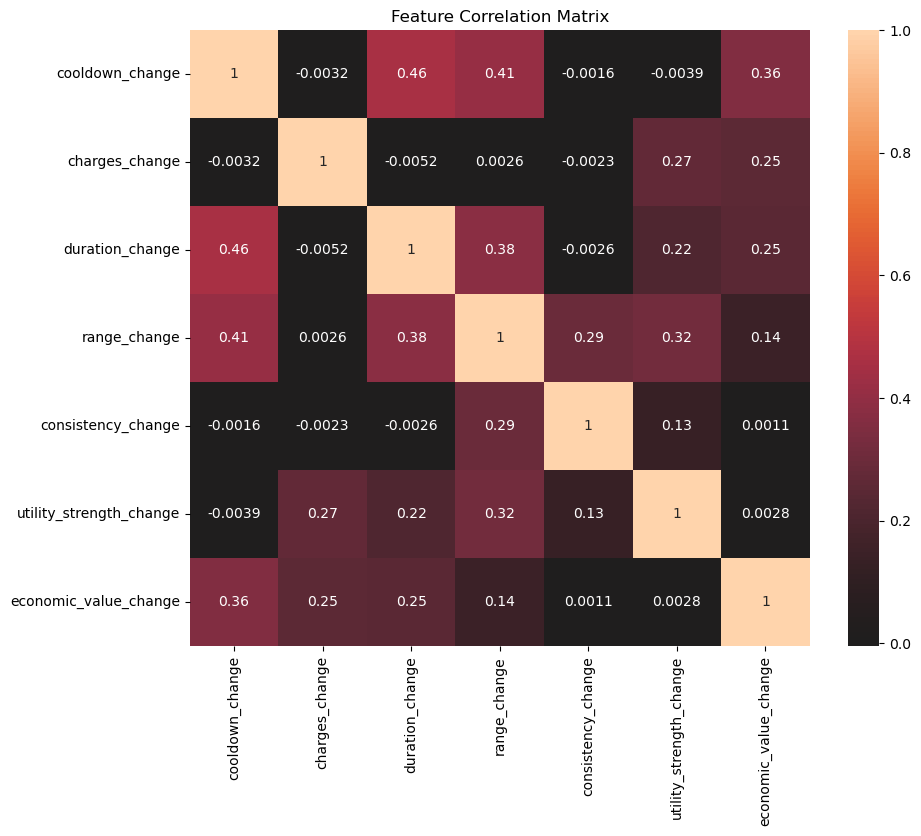

In [18]:
corr = valorant_model_df[feature_cols].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    center=0
)

plt.title("Feature Correlation Matrix")

plt.show()

In [19]:
model_df[model_features].corr()

,cooldown_change,charges_change,duration_change,range_change,consistency_change,utility_strength_change,economic_value_change,prev_pick_rate
cooldown_change,1.000000,-0.003428,0.456928,0.411048,-0.001711,-0.004204,0.355906,-0.131567
charges_change,-0.003428,1.000000,-0.005516,0.002798,-0.002423,0.267867,0.253180,-0.153358
duration_change,0.456928,-0.005516,1.000000,0.379289,-0.002753,0.215489,0.246994,-0.163628
range_change,0.411048,0.002798,0.379289,1.000000,0.290479,0.319100,0.143145,-0.150870
consistency_change,-0.001711,-0.002423,-0.002753,0.290479,1.000000,0.133690,0.001209,-0.111275
utility_strength_change,-0.004204,0.267867,0.215489,0.319100,0.133690,1.000000,0.002971,-0.159202
economic_value_change,0.355906,0.253180,0.246994,0.143145,0.001209,0.002971,1.000000,-0.070600
prev_pick_rate,-0.131567,-0.153358,-0.163628,-0.150870,-0.111275,-0.159202,-0.070600,1.000000


## Linear Regression Modeling

Linear regression was used as the primary modeling approach to evaluate relationships between patch balance changes and professional pick-rate movement. Standardized predictors were used to improve coefficient comparability across variables.

In [20]:
X = model_df[
    feature_cols + ["prev_pick_rate"]
]

y = model_df["delta_pick_rate"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)

preds = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("R2:", r2_score(y_test, preds))

MAE: 8.309899116146775
RMSE: 11.999765556779654
R2: 0.10122347275744137


In [21]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lr.coef_
}).sort_values("coefficient", ascending=False)

coef_df

,feature,coefficient
5,utility_strength_change,3.436567
4,consistency_change,1.969314
0,cooldown_change,0.000000
2,duration_change,-0.049407
7,prev_pick_rate,-0.194782
3,range_change,-3.602333
6,economic_value_change,-7.450634
1,charges_change,-20.852365


## Findings 
The regression results showed that some balance categories appeared to have stronger relationships with professional pick-rate movement than others. Utility strength changes had one of the strongest positive relationships with pick-rate increases, which suggests that direct improvements to an agent’s utility effectiveness may have a noticeable impact on professional usage. This makes sense within competitive Valorant since strong utility often shapes executes, site control, and team coordination.

Charge-related changes showed the strongest negative relationship in the model. This may suggest that adjustments affecting the number of times abilities can be used have a large impact on professional viability. However, this result should be interpreted carefully because charge-related updates are often tied to larger balance reworks rather than isolated adjustments.

Economic value and range-related changes also showed negative relationships with pick-rate movement, suggesting that cost efficiency and utility reach may influence how consistently agents are selected in professional play. On the other hand, cooldown and duration changes showed relatively small relationships in the model, which may indicate that these adjustments alone are not strong drivers of professional meta shifts.

Previous pick rate still contributed to the model, although it was not as dominant as earlier versions of the analysis. This suggests that existing meta popularity and professional familiarity still play a role in future agent selection, even after accounting for patch adjustments.

Overall, the regression results suggest that balance changes may contribute to professional pick-rate movement, but they likely work alongside many other competitive factors such as team strategy, map pools, coaching adaptation, and evolving tournament metas.

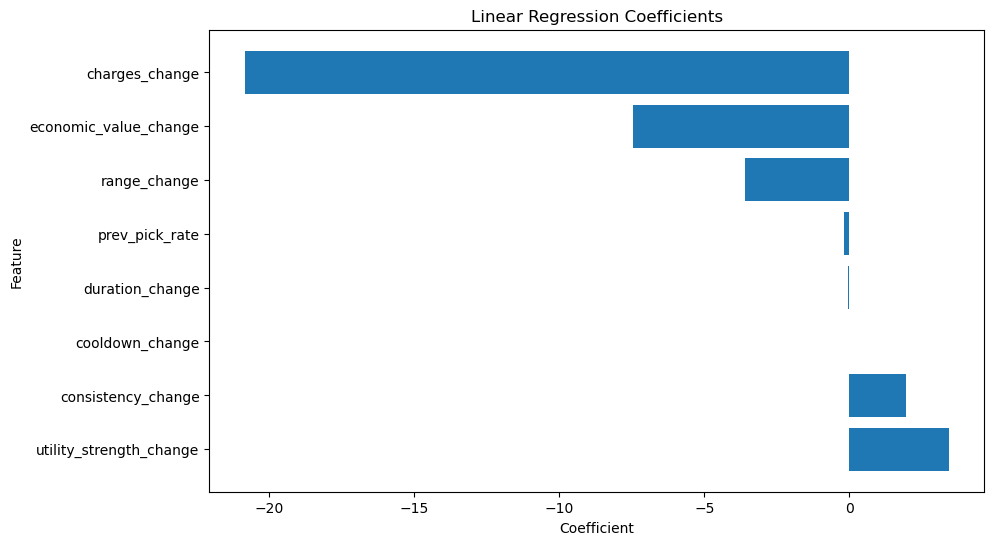

In [22]:
plt.figure(figsize=(10,6))

plt.barh(
    coef_df["feature"],
    coef_df["coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Linear Regression Coefficients")

plt.show()

## Decision Tree Exploration

A decision tree regressor was used as a secondary exploratory model to evaluate whether nonlinear or hierarchical balance patterns existed within professional pick-rate movement.

In [23]:
tree_features = [
    "cooldown_change",
    "duration_change",
    "charges_change",
    "economic_value_change",
    "range_change",
    "consistency_change",
    "utility_strength_change"
]
X_tree = model_df[tree_features]

y_tree = model_df["delta_pick_rate"]

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree,
    y_tree,
    test_size=0.2,
    random_state=42
)

tree = DecisionTreeRegressor(
    max_depth=4,
    random_state=42
)

tree.fit(X_train_tree, y_train_tree)


,criterion,'squared_error'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [24]:
tree_preds = tree.predict(X_test_tree)


In [25]:
print("Decision Tree Metrics")
print("----------------------")

print(
    "MAE:",
    mean_absolute_error(y_test_tree, tree_preds)
)

print(
    "RMSE:",
    np.sqrt(mean_squared_error(y_test_tree, tree_preds))
)

print(
    "R2:",
    r2_score(y_test_tree, tree_preds)
)

Decision Tree Metrics
----------------------
MAE: 6.938073523383577
RMSE: 13.064193212707073
R2: -0.06529867998120875


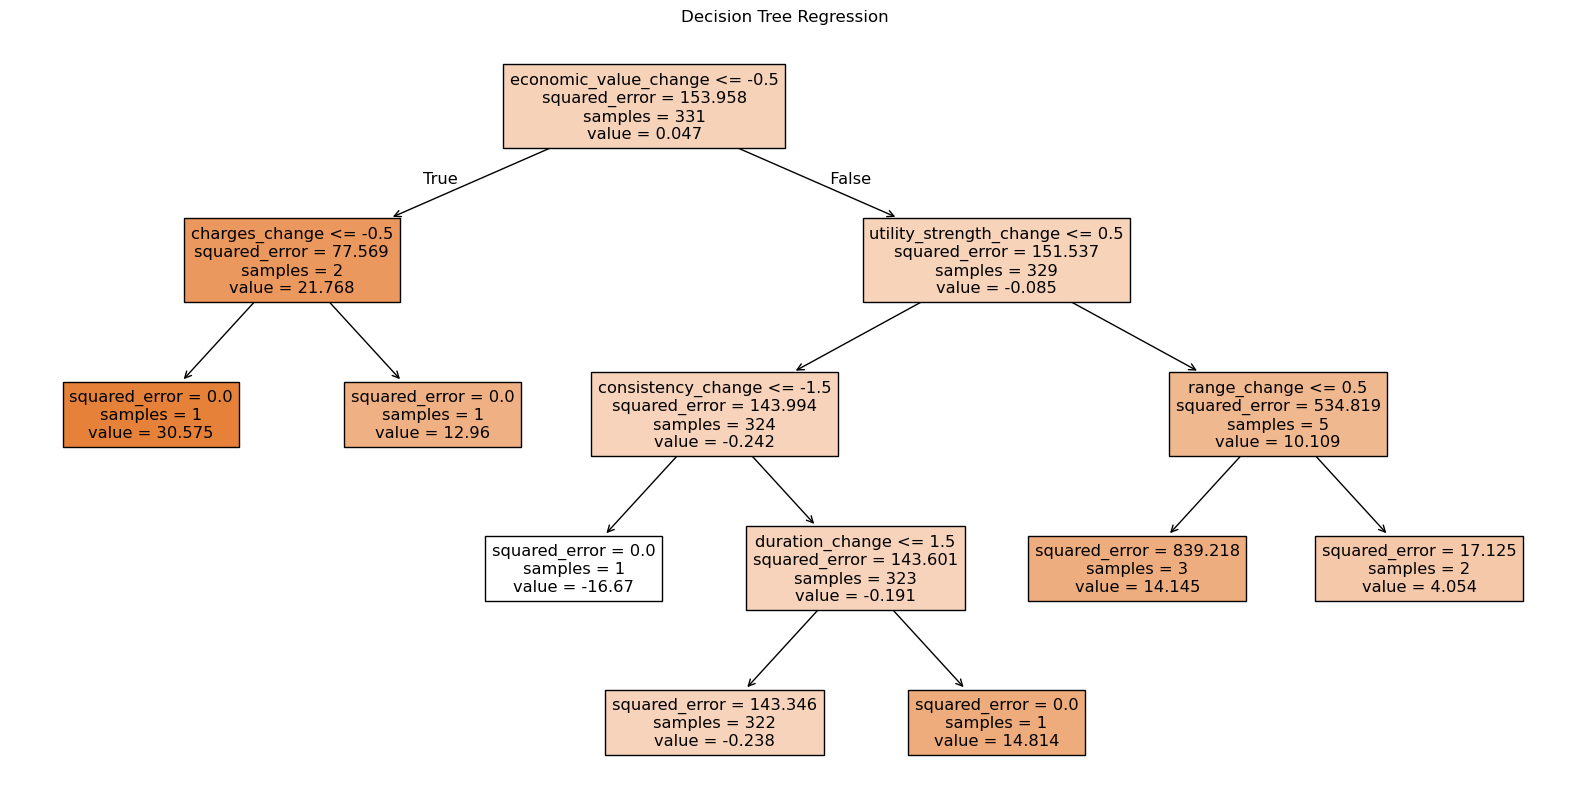

In [26]:
plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X_tree.columns,
    filled=True
)

plt.title("Decision Tree Regression")

plt.show()

In [27]:
importance_df = pd.DataFrame({
    "Feature": X_tree.columns,
    "Importance": tree.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

print(importance_df)

                   Feature  Importance
3    economic_value_change    0.421767
6  utility_strength_change    0.234402
5       consistency_change    0.120273
1          duration_change    0.100342
2           charges_change    0.068927
4             range_change    0.054290
0          cooldown_change    0.000000


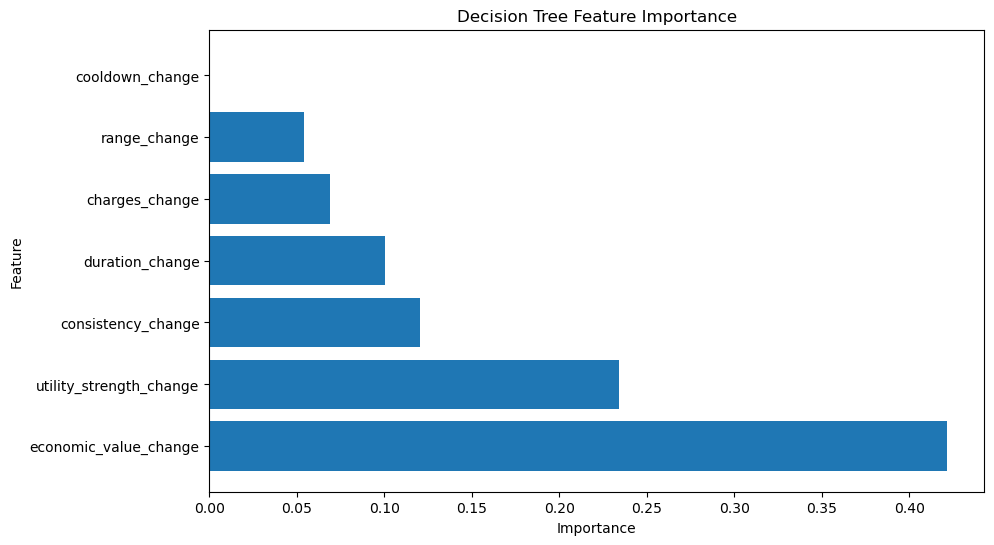

In [28]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Decision Tree Feature Importance")

plt.show()